# PRCP-1021-Insurance Cost prediction


## Problem Statement

The objective is to build a machine learning model to predict insurance charges using various features like age, BMI, gender, smoking habits, and region.

# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [2]:
df = pd.read_csv('insurance_cost_prediction.csv')

In [4]:
df.head()     #It will show top 5 records of the Dataset

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.tail()     #It will show top 5 records from the bottom

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


# Basic Check

In [6]:
df.shape      #It will show number of rows and column present in Dataset


(1338, 7)

In [7]:
df.info()     #It will show the data types and missing values presesent in dataset


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
df.describe()     #It will describe the statistical summary (mean, min, max, count etc)


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# Check Null Values

In [9]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

##### Checks if any column has missing values.
##### Important because ML models cannot handle null values directly.

# Exploratory Data Analysis (EDA)

## Distribution of Charges

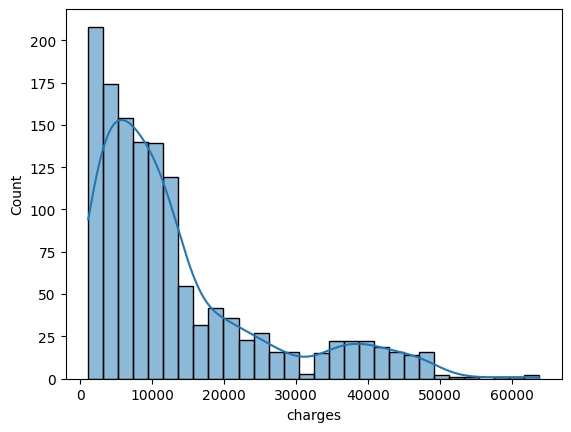

In [10]:
sns.histplot(df['charges'], kde=True)
plt.show()

##### It Shows how insurance cost is distributed
##### If skewed then may need transformation
##### Usually right-skewed (few people have very high cost)

## Smoker vs Charges

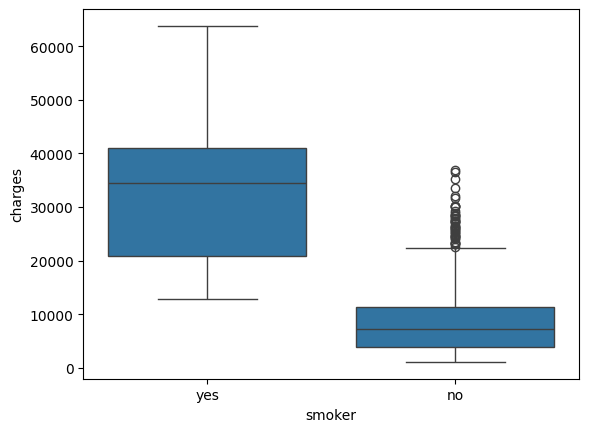

In [11]:
sns.boxplot(x='smoker', y='charges', data=df)
plt.show()

##### It Compare smokers vs non-smokers
##### Smokers usually have much higher charges
##### It is the Important feature for prediction

## Age vs Charges

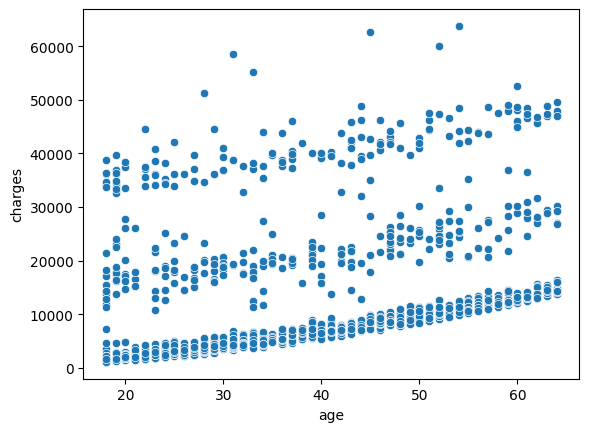

In [12]:
sns.scatterplot(x='age', y='charges', data=df)
plt.show()

##### It Shows relationship between age and cost
##### Those who's age is higher cost will be higher

## BMI vs Charges

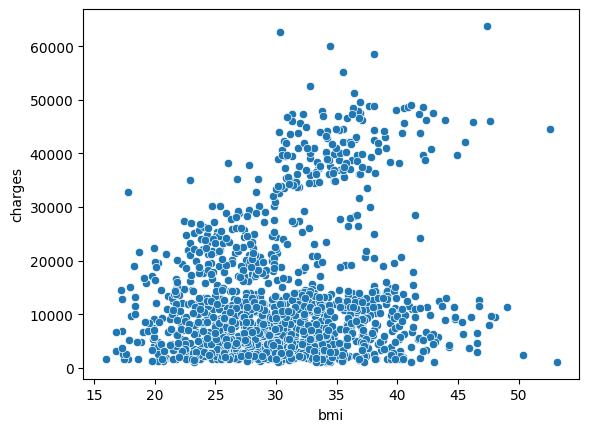

In [13]:
sns.scatterplot(x='bmi', y='charges', data=df)
plt.show()

##### Anyone having higher BMI it affects higher health risk then charges will be higher
##### It Helps identify trends or outliers

## Correlation Heatmap

                       age       sex       bmi  children    smoker   charges  \
age               1.000000 -0.020856  0.109272  0.042469 -0.025019  0.299008   
sex              -0.020856  1.000000  0.046371  0.017163  0.076185  0.057292   
bmi               0.109272  0.046371  1.000000  0.012759  0.003750  0.198341   
children          0.042469  0.017163  0.012759  1.000000  0.007673  0.067998   
smoker           -0.025019  0.076185  0.003750  0.007673  1.000000  0.787251   
charges           0.299008  0.057292  0.198341  0.067998  0.787251  1.000000   
region_northwest -0.000407 -0.011156 -0.135996  0.024806 -0.036945 -0.039905   
region_southeast -0.011642  0.017117  0.270025 -0.023066  0.068498  0.073982   
region_southwest  0.010016 -0.004184 -0.006205  0.021914 -0.036945 -0.043210   

                  region_northwest  region_southeast  region_southwest  
age                      -0.000407         -0.011642          0.010016  
sex                      -0.011156          0.017117 

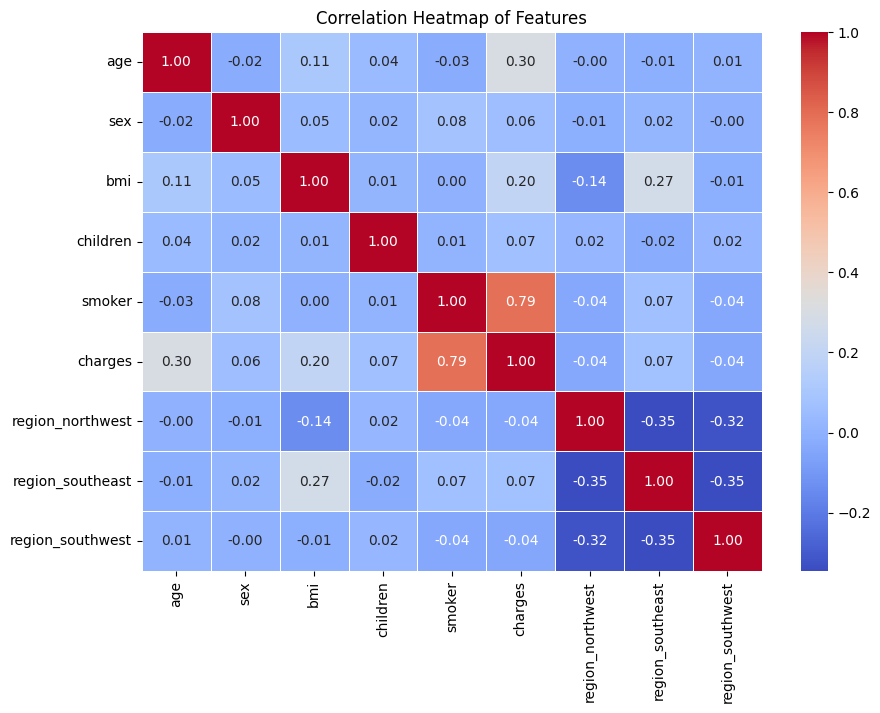

In [19]:
# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Print correlation table (optional but useful)
print(corr_matrix)

# Plot heatmap
plt.figure(figsize=(10, 7))  # Increase size for better readability
sns.heatmap(
    corr_matrix,
    annot=True,        # Show values
    fmt=".2f",         # Limit to 2 decimal places
    cmap="coolwarm",   # Color theme
    linewidths=0.5     # Add spacing between cells
)

plt.title("Correlation Heatmap of Features")
plt.show()

##### It Shows correlation between variables
##### It Helps to identify important features
##### Smokers strongly corelate with charges

# Data Preprocessing

## Convert Categorical → Numerical

In [16]:
df['sex'] = df['sex'].map({'male':1, 'female':0})
df['smoker'] = df['smoker'].map({'yes':1, 'no':0})
df = pd.get_dummies(df, columns=['region'], drop_first=True)

In [20]:
df[['smoker', 'charges']].corr()

,smoker,charges
smoker,1.000000,0.787251
charges,0.787251,1.000000


## Define X and y

In [21]:
X = df.drop('charges', axis=1)
y = df['charges']

##### X is input features here
##### y is target variable

## Train Test Split

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##### Here I imported train_test_split from sklearn.model_prediction
##### I used 80% training and 20% for Testing
##### random_state ensures reproducibility

# Model Building

## Linear Regression

In [23]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


##### Assumes linear relationship
##### Simple baseline model for regression problem

## Decision Tree

In [25]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


##### It captures non-linear patterns
##### It can overfit if not controlled

## Random Forest

In [26]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


##### It ensemble of multiple trees
##### It usually reduces overfitting


# Model Evaluation

In [28]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def evaluate(model):
    pred = model.predict(X_test)
    
    print("Model:", model.__class__.__name__)
    print("R2 Score:", r2_score(y_test, pred))
    print("MAE:", mean_absolute_error(y_test, pred))
    print("MSE:", mean_squared_error(y_test, pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
    print("-"*30)

In [29]:
evaluate(lr)

Model: LinearRegression
R2 Score: 0.7835929767120724
MAE: 4181.194473753648
MSE: 33596915.851361446
RMSE: 5796.284659276272
------------------------------


In [30]:
evaluate(dt)

Model: DecisionTreeRegressor
R2 Score: 0.7265877305258355
MAE: 3195.1104733805973
MSE: 42446908.010150984
RMSE: 6515.129162967606
------------------------------


In [31]:
evaluate(rf)

Model: RandomForestRegressor
R2 Score: 0.8650185799366616
MAE: 2550.67015143483
MSE: 20955694.239791505
RMSE: 4577.738987730898
------------------------------


##### In this project we use R² score, MAE, MSE and RMSE, which measure how close the predicted values are to the actual values and give a better understanding of model performance.

# Model Comparison

##### Random Forest is Good because it gives less MAE, MSE, RMSE and R2 high as compared to another model

# Feature Importance

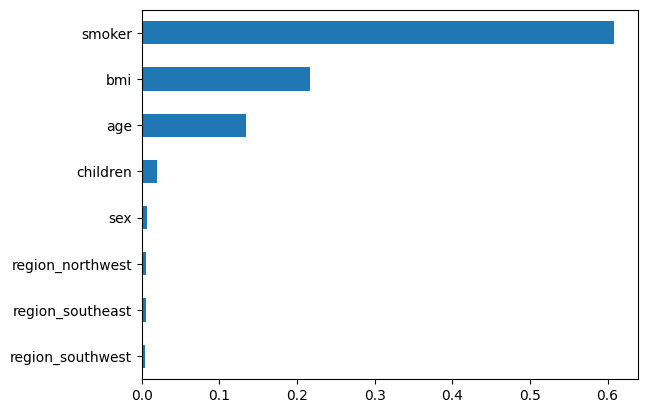

In [32]:
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh')
plt.show()

##### It shows which features impact prediction most
##### smoker has highest impact
##### age, bmi have moderate impact

# Final Prediction

In [33]:
sample = X_test.iloc[[0]]
prediction = rf.predict(sample)

print("Predicted Insurance Cost:", prediction[0])

Predicted Insurance Cost: 9627.216016399998


### Explanation:
A sample input is taken from the test dataset and passed to the trained model to predict insurance cost, demonstrating real-world usage.

## Challenges Faced

Handling categorical variables was a key challenge, as they required proper encoding to be used in machine learning models. The dataset also showed skewness in insurance charges due to extreme values, making it harder to model accurately. Identifying the most relevant features and comparing multiple models to select the best-performing one were additional challenges during the development process.

## Key Business Insight

Smoking status is the most significant factor affecting insurance charges, with smokers incurring much higher costs. Age and BMI also show a positive relationship with charges, indicating that health and age-related risks increase insurance expenses. In contrast, the number of children and region have minimal impact on cost variation.

## Conclusion

The project successfully developed an insurance cost prediction model using multiple regression techniques. Among the models, ensemble methods performed better in capturing complex relationships within the data. The analysis highlights key factors influencing insurance charges and demonstrates how machine learning can support data-driven pricing decisions in the insurance industry.
* Deployed on Streamlit and here is the link : https://insurancecost-predictor.streamlit.app/